### Step 1 - The Configure MLflow tracking location

In [11]:
!pip install mlflow scikit-learn --quiet

In [12]:
import mlflow
import os

# set the tracking location to our root directory
project_root = os.path.abspath("..")
mlflow.set_tracking_uri(f"file:///{project_root}/mlruns")

print(f"MLflow tracking at: {project_root}/mlruns")

MLflow tracking at: c:\Users\Admin\OneDrive\Documents\GitHub\Muinat_Ridewise_Europe/mlruns


### Step 2 - Loading the Mlflow

In [13]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Set tracking directory OUTSIDE notebooks
mlflow.set_tracking_uri(
    "file:///c:/Users/Admin/OneDrive/Documents/GitHub/Muinat_Ridewise_Europe/mlruns"
)

print(f"MLflow version: {mlflow.__version__}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print("MLflow loaded successfully!")


MLflow version: 3.6.0
MLflow tracking URI: file:///c:/Users/Admin/OneDrive/Documents/GitHub/Muinat_Ridewise_Europe/mlruns
MLflow loaded successfully!


### Step 3 - Import Standard Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    mean_squared_error,
    classification_report,
    f1_score
)

### Step 4 - Setting up MLflow Experiment

- Experiment like a project folder
- Every model run goes inside it

In [15]:
# set up a folder for our mlflow experiment
EXPERIMENT_NAME = "RideWise-Churn-Prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

# Make sure that MLFLOW EXPERIMENT_NAME is set to the name of your experiment
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print(f"Experiment name: {experiment.name}")
print(f"Experiment ID: {experiment.experiment_id}")
print(f"Experiment artifact location: {experiment.artifact_location}")

Experiment name: RideWise-Churn-Prediction
Experiment ID: 969808953743187709
Experiment artifact location: file:///c:/Users/Admin/OneDrive/Documents/GitHub/Muinat_Ridewise_Europe/mlruns/969808953743187709


### Step 5 - Load Processed Data

In [16]:
model_df = pd.read_csv("../data/processed/model_clustered.csv")
features = pd.read_csv("../data/processed/features.csv")
target = pd.read_csv("../data/processed/target.csv")

print(f"Features shape: {features.shape}")
print(f"Target shape: {target.shape}")

Features shape: (3000, 16)
Target shape: (3000, 1)


### Step 6 - Preprocessing
#### Step 6a: Encoding Categorical features

In [ ]:
# Label encoding for binary categories
le = LabelEncoder()
features['gender'] = le.fit_transform(features['gender'])

# One-hot encoding for multi-class categorical variables
features = pd.get_dummies(features,
    columns=[
        "city",
        "income_level",
        "signup_channel",
        "persona",
        "Cluster"
    ],
    drop_first=True, dtype=int
)

#### Step 6b: Scaling numerical features

In [ ]:
scaler = StandardScaler()

# Scale Features
num_cols_to_scale = ['age', 'total_trips', 'days_since_last_trip',
       'trips_30d','completed_trips_30d', 'cancelled_trips_30d', 'total_fare_30d',
       'total_distance_30d', 'promo_used_trips_30d', 'total_events_30d']

features[num_cols_to_scale] = scaler.fit_transform(features[num_cols_to_scale])

target.value_counts()
target.value_counts(normalize=True)

print(f"Target value counts: {target.value_counts()}")
print(f"Target value counts (normalized): {target.value_counts(normalize=True)}")

Target value counts: churned
0          2451
1           549
Name: count, dtype: int64
Target value counts (normalized): churned
0          0.817
1          0.183
Name: proportion, dtype: float64


#### Step 6b1: Target plot

<Axes: xlabel='churned', ylabel='count'>

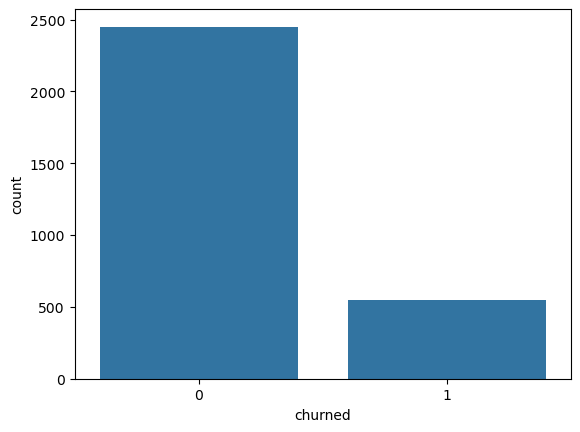

In [22]:
sns.countplot(x="churned", data=model_df)

### Step 6c: Class Imbalance
#### Step 6c1: Apply SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

# Seperate features and target
X = features
y = target

# Apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

y_resampled.value_counts()

churned
0          2451
1          2451
Name: count, dtype: int64

In [24]:
resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
resampled_df.head(3)

,age,gender,total_trips,days_since_last_trip,trips_30d,completed_trips_30d,cancelled_trips_30d,total_fare_30d,total_distance_30d,promo_used_trips_30d,...,income_level_medium,signup_channel_Organic,signup_channel_Partnership,signup_channel_Referral,persona_Casual Rider,persona_Commuter,persona_Tourist,Cluster_1,Cluster_2,Cluster_3
0,-1.609945,2,1.542709,-0.008398,-0.178564,-0.081715,-0.548000,-0.171966,-0.296500,-0.605223,...,0,0,0,0,0,0,1,0,0,1
1,1.218616,2,0.731158,1.323412,-0.824753,-0.813493,-0.548000,-0.778533,-0.803754,-0.605223,...,0,0,1,0,0,0,0,0,0,0
2,-0.801785,1,0.362271,-0.896271,0.036833,-0.081715,0.561311,0.089854,0.103600,0.415389,...,0,0,0,0,0,0,0,0,0,1


In [25]:
resampled_df["churned"] = y_resampled
resampled_df.head(3)

,age,gender,total_trips,days_since_last_trip,trips_30d,completed_trips_30d,cancelled_trips_30d,total_fare_30d,total_distance_30d,promo_used_trips_30d,...,signup_channel_Organic,signup_channel_Partnership,signup_channel_Referral,persona_Casual Rider,persona_Commuter,persona_Tourist,Cluster_1,Cluster_2,Cluster_3,churned
0,-1.609945,2,1.542709,-0.008398,-0.178564,-0.081715,-0.548000,-0.171966,-0.296500,-0.605223,...,0,0,0,0,0,1,0,0,1,0
1,1.218616,2,0.731158,1.323412,-0.824753,-0.813493,-0.548000,-0.778533,-0.803754,-0.605223,...,0,1,0,0,0,0,0,0,0,0
2,-0.801785,1,0.362271,-0.896271,0.036833,-0.081715,0.561311,0.089854,0.103600,0.415389,...,0,0,0,0,0,0,0,0,1,0


### Step 7: Data Splitting

In [27]:
# Split the dataset (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, 
                                                    random_state=42, stratify=y_resampled)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

print(f"y_train value counts distribution: {y_train.value_counts(normalize=True)}")
print(f"y_test value counts distribution: {y_test.value_counts(normalize=True)}")

Training set size: 3431
Testing set size: 1471
y_train value counts distribution: churned
1          0.500146
0          0.499854
Name: proportion, dtype: float64
y_test value counts distribution: churned
0          0.50034
1          0.49966
Name: proportion, dtype: float64


### Step 8 - Helper Function- Metric calculation (accuracy etc)

In [30]:
def calculate_metrics(y_true, y_pred_proba, top_percentile=15):
    y_true = y_true.values.ravel()  # flatten the target array if it's a DataFrame
    y_pred_proba = y_pred_proba.ravel()  # flatten the predicted probabilities if needed

    # step 7a - calculate the AUC_ROC score
    # if AUC_ROC is 0.61 (the model is right 61 times out of 100 when its comparing
    # churners vs non-churners)
    auc = roc_auc_score(y_true, y_pred_proba)

    # step 7b - calculate the precious Top 15% or riskest customers
    # Find the minimum score/probaility to be in the top 15% of risk
    threshold = np.percentile(y_pred_proba, 100 - top_percentile)


    # filter the 15% from the general probabilyt data
    # e.g probab 0.72 >= 0.70 (threshold) --> 1 (target)
    # e.g probab 0.65 <= 0.70 (threshold) --> 0 (ignore)
    pred_top = (y_pred_proba >= threshold).astype(int)


    # what happens behind the scene 
    # pred_prob = [0.72, 0.65, 0.80, 0.55, 0.90]
    # threshold = 0.70
    # pred_top = [1,0,1,1,1,0]
    # pred_top.sum() --- 4 (4 customers are in the top 15% of risk)
    # if pred_top.sum() greater than 0 (the model can somehow select 0 customers)
    # division by zero will crash the program 

     # safety check
    if pred_top.sum() > 0:
        precision_at_k = (pred_top[y_true == 1].sum())/ pred_top.sum()
        recall_at_k = (pred_top[y_true == 1].sum())/ (y_true == 1).sum()
    
    else:
        precision_at_k = 0.0
        recall_at_k = 0.0
    
    y_pred = (y_pred_proba >= 0.5).astype(int)

    return {
        "auc_roc": auc,
        f"precision_at_{top_percentile}": precision_at_k,
        f"recall_at_{top_percentile}": recall_at_k,

        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score" : f1_score(y_true, y_pred)
    }

### Step 9 - Experiment 1 - Baseline Logistic regression

In [31]:
with mlflow.start_run(run_name="Logistic Regression"):
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("n_features", X_train.shape[1])

    # step 8a - train the model

    model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train,y_train)

    # step 8b - make predictions
    y_pred_proba = model.predict_proba(X_test)[:,1]

    # step 8c - calculate metrics
    metrics = calculate_metrics(y_test, y_pred_proba)

    # step 8d - log metrics to mlflow
    for metric_name, metric_value in metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # step 8e - log the signature of the model (input and output schema)
    signature = infer_signature(X_train, y_pred_proba)
    mlflow.sklearn.log_model(
        model,
        "model", 
        signature=signature
        )


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more detai